In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sc2ts
import tskit
import tszip

In [2]:
data_dir = Path("../data")
csv_file = data_dir / "recombinants.csv"
df = pd.read_csv(csv_file)
df.head(2)

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,num_mns_left,mns_left,num_mns_right,mns_right
0,1438470,SRR19695004,1,1,1,519,670,2,COVID-AMPLISEQ-V1,.,...,True,3,2,55,False,6,1,mnS1,1,MNM3
1,1540083,ERR9939974,1,1,1,695,958,1,COVID-ARTIC-V4.1,.,...,False,4,1,12,False,9,0,NaN,1,MNM3


In [3]:
ts_file = data_dir / "sc2ts_viridian_v2.2.trees.tsz"
ts = tszip.decompress(ts_file)

In [4]:
df = df[df.net_min_supporting_loci_lft_rgt_ge_4].reset_index(drop=True)
len(df)

647

In [5]:
ds = sc2ts.Dataset(data_dir / "viridian_mafft_2024-10-14_v1.vcz.zip", date_field="Date_tree")
md = ds.metadata.as_dataframe(["Country", "Region", "Date_tree"])
md = md[(md["Date_tree"].str.len() == 10) & (md["Country"] != "UNKNOWN")]
md["day"] = (pd.to_datetime(md["Date_tree"]) - pd.Timestamp("2020-01-01")).dt.days
country_by_run = md["Country"].to_dict()
region_by_run = md["Region"].to_dict()
len(md)

4458819

In [6]:
# Days on which each Pango lineage was sampled in each country, used below as a
# proxy for the circulation of that lineage in that country.
pango = ds.metadata.as_dataframe(["Viridian_pangolin"])
circulation = (
    md.join(pango)
    .groupby(["Viridian_pangolin", "Country"])["day"]
    .apply(lambda s: np.sort(s.to_numpy()))
    .to_dict()
)

WINDOW = 28


def is_circulating(pango, country, day):
    days = circulation.get((pango, country))
    if days is None:
        return False
    return bool(((days >= day - WINDOW) & (days <= day + WINDOW)).any())

In [7]:
df["day"] = (pd.to_datetime(df.recombinant_date) - pd.Timestamp("2020-01-01")).dt.days
df["sample_country"] = df.sample_id.map(country_by_run)

both_parent_lineages_local = np.array(
    [
        is_circulating(row.parent_left_pango, row.sample_country, row.day)
        and is_circulating(row.parent_right_pango, row.sample_country, row.day)
        for row in df.itertuples()
    ]
)
print(f"Events with a known sampling country: {df.sample_country.notna().sum()} of {len(df)}")
print(
    f"Both parent lineages sampled in that country within {WINDOW} days: "
    f"{both_parent_lineages_local.sum()} ({both_parent_lineages_local.mean():.1%})"
)

Events with a known sampling country: 647 of 647
Both parent lineages sampled in that country within 28 days: 538 (83.2%)


In [8]:
def blocked_permutation(days, block_size, rng):
    # Permute events within blocks of events adjacent in time, so that the null
    # preserves when each event occurred, and hence the sampling composition
    # of the dataset at that time.
    perm = np.arange(len(days))
    order = np.argsort(days)
    for start in range(0, len(order), block_size):
        block = order[start : start + block_size]
        perm[block] = rng.permutation(block)
    return perm

In [9]:
# Null for the lineage-level measure above: pair each event's left parent lineage
# with the right parent lineage of a time-matched event.
for block_size in (10, 20, 40):
    rng = np.random.default_rng(42)
    replicates = []
    for _ in range(20):
        perm = blocked_permutation(df.day.to_numpy(), block_size, rng)
        replicates.append(
            np.mean(
                [
                    is_circulating(df.parent_left_pango[i], df.sample_country[i], df.day[i])
                    and is_circulating(df.parent_right_pango[p], df.sample_country[i], df.day[i])
                    for i, p in enumerate(perm)
                ]
            )
        )
    print(f"block size {block_size}: null {np.mean(replicates):.1%}")

block size 10: null 81.0%


block size 20: null 79.9%


block size 40: null 78.9%


In [10]:
parent_left_is_sample = ts.nodes_flags[df.parent_left.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
parent_right_is_sample = ts.nodes_flags[df.parent_right.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
df["parent_left_is_sample"] = parent_left_is_sample
df["parent_right_is_sample"] = parent_right_is_sample
sub_df = df[df.parent_left_is_sample & df.parent_right_is_sample].reset_index(drop=True)
len(sub_df)

224

In [11]:
accession_by_node = {
    int(node_id): ts.node(id_=int(node_id)).metadata["sample_id"]
    for node_id in pd.unique(sub_df[["parent_left", "parent_right"]].to_numpy().ravel())
}

for side in ("left", "right"):
    accessions = sub_df[f"parent_{side}"].map(accession_by_node)
    sub_df[f"parent_{side}_accession"] = accessions
    sub_df[f"parent_{side}_country"] = [country_by_run.get(x) for x in accessions]
    sub_df[f"parent_{side}_region"] = [region_by_run.get(x) for x in accessions]

sub_df["abs_parent_time_diff"] = (sub_df.parent_left_time - sub_df.parent_right_time).abs().round(1)
sub_df[["parent_left_country", "parent_right_country", "abs_parent_time_diff"]].head()

,parent_left_country,parent_right_country,abs_parent_time_diff
0,United Kingdom,United Kingdom,2.0
1,USA,USA,16.0
2,United Kingdom,United Kingdom,30.0
3,USA,United Kingdom,76.0
4,United Kingdom,United Kingdom,9.0


In [12]:
same_country = sub_df.parent_left_country == sub_df.parent_right_country
obs_same_country = same_country.mean()
obs_time_diff = sub_df.abs_parent_time_diff.median()

print(f"Recombinants with both parents sampled: {len(sub_df)}")
print(f"Parents sampled in the same country: {same_country.sum()} ({obs_same_country:.1%})")
for label in ("USA", "United Kingdom", "Denmark"):
    n = sum((sub_df.parent_left_country == label) & (sub_df.parent_right_country == label))
    print(f"    {label}: {n}")
print(f"Median absolute difference in parent times: {obs_time_diff:.0f} days")
both_local = (sub_df.parent_left_country == sub_df.sample_country) & (
    sub_df.parent_right_country == sub_df.sample_country
)
print(f"Both parents sampled in the recombinant's own country: {both_local.mean():.1%}")

Recombinants with both parents sampled: 224
Parents sampled in the same country: 134 (59.8%)
    USA: 70
    United Kingdom: 52
    Denmark: 8
Median absolute difference in parent times: 25 days
Both parents sampled in the recombinant's own country: 54.5%


In [13]:
# Null distributions for the same-country fraction and the parent time difference.
null_same_country = {}
for block_size in (10, 20, 40, len(sub_df)):
    rng = np.random.default_rng(42)
    same, time_diff = [], []
    for _ in range(1000):
        perm = blocked_permutation(sub_df.day.to_numpy(), block_size, rng)
        same.append(
            np.mean(sub_df.parent_left_country.to_numpy() == sub_df.parent_right_country.to_numpy()[perm])
        )
        time_diff.append(
            np.median(
                np.abs(sub_df.parent_left_time.to_numpy() - sub_df.parent_right_time.to_numpy()[perm])
            )
        )
    same, time_diff = np.array(same), np.array(time_diff)
    null_same_country[block_size] = same
    print(
        f"block size {block_size}: "
        f"same country {same.mean():.1%} (p = {(same >= obs_same_country).mean():.4f}), "
        f"median time difference {time_diff.mean():.0f} days "
        f"(p = {(time_diff <= obs_time_diff).mean():.4f})"
    )

block size 10: same country 41.1% (p = 0.0000), median time difference 34 days (p = 0.0010)


block size 20: same country 40.3% (p = 0.0000), median time difference 41 days (p = 0.0000)


block size 40: same country 39.5% (p = 0.0000), median time difference 55 days (p = 0.0000)


block size 224: same country 33.9% (p = 0.0000), median time difference 204 days (p = 0.0000)


In [14]:
# Region is only populated for a few countries, so sub-national resolution is
# limited to the USA.
usa = sub_df[(sub_df.parent_left_country == "USA") & (sub_df.parent_right_country == "USA")]
print(f"USA-USA parent pairs: {len(usa)}")
print(f"    sampled in the same state: {np.mean(usa.parent_left_region == usa.parent_right_region):.1%}")
print("UK regions:", sub_df[sub_df.parent_left_country == "United Kingdom"].parent_left_region.unique())

USA-USA parent pairs: 70
    sampled in the same state: 17.1%
UK regions: <StringArray>
['none']
Length: 1, dtype: str


In [15]:
def create_histogram(ax):
    ax.hist(
        sub_df["abs_parent_time_diff"],
        bins=50,
        color="#4477AA",
        edgecolor="white",
        linewidth=0.6,
    )

    ax.axvline(
        obs_time_diff,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Median",
    )
    ax.legend(frameon=False)

    ax.set(
        xlabel="Absolute difference in parent times",
        ylabel="Number of recombination events",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.01)

    return ax


def create_heatmap(ax, cofreq):
    fig = ax.figure
    im = ax.imshow(cofreq, cmap="viridis", aspect="equal")

    fig.colorbar(im, ax=ax, label="Number of recombination events")

    for (i, j), value in np.ndenumerate(cofreq):
        ax.text(
            j, i, f"{value:.2g}",
            ha="center",
            va="center",
            color="white" if im.norm(value) < 0.5 else "black",
        )

    ax.set_xticks(
        np.arange(cofreq.shape[1]),
        labels=getattr(cofreq, "columns", np.arange(cofreq.shape[1])),
    )
    ax.set_yticks(
        np.arange(cofreq.shape[0]),
        labels=getattr(cofreq, "index", np.arange(cofreq.shape[0])),
    )

    ax.set_ylabel("Country of left parent")
    ax.set_xlabel("Country of right parent")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    return ax


def create_null_plot(ax, block_size=20):
    ax.hist(
        100 * null_same_country[block_size],
        bins=30,
        color="0.7",
        edgecolor="white",
        linewidth=0.6,
        label="Permuted parents",
    )

    ax.axvline(
        100 * obs_same_country,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Observed",
    )
    ax.legend(frameon=False)

    ax.set(
        xlabel="Parents sampled in the same country (%)",
        ylabel="Number of permutation replicates",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.tick_params(axis="both", labelsize=10)

    return ax

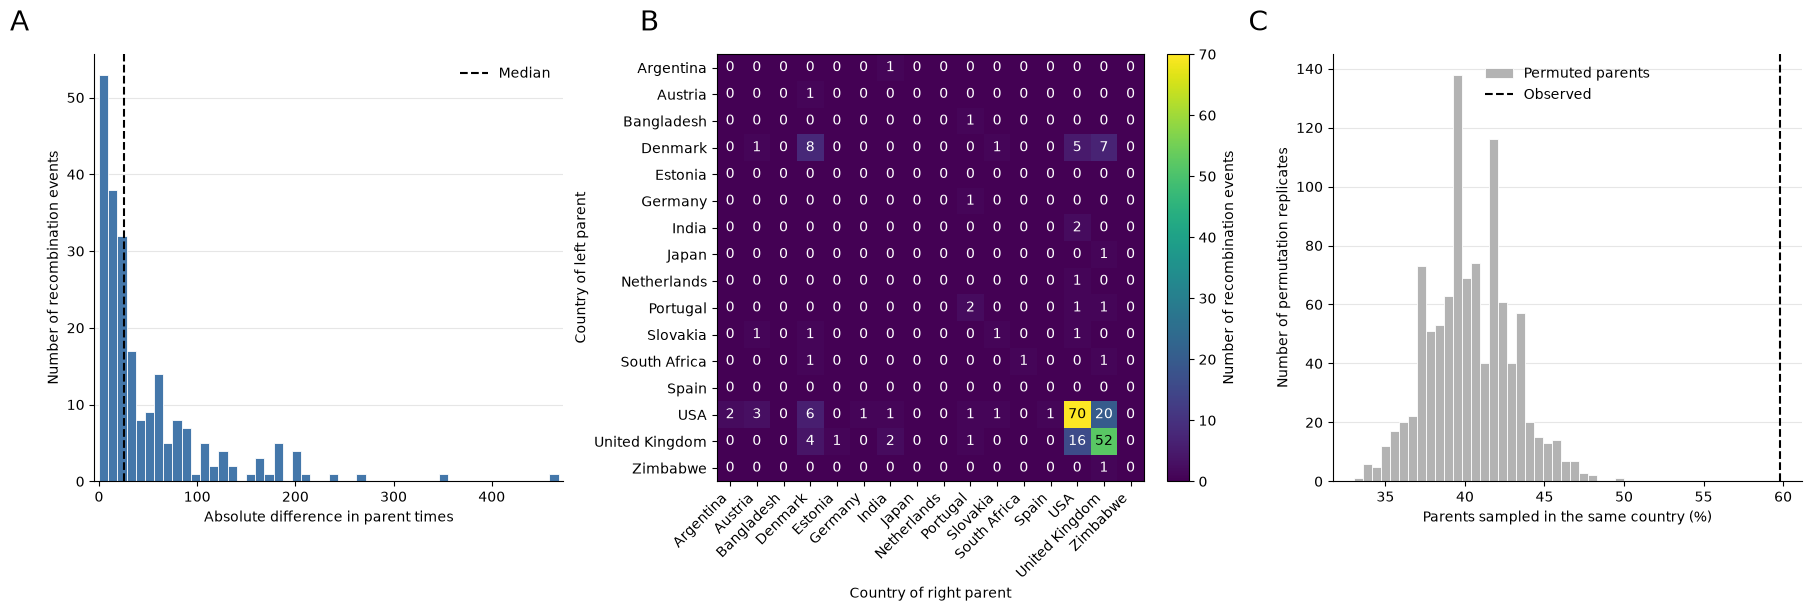

In [16]:
labels = pd.Index(sub_df["parent_left_country"]).union(pd.Index(sub_df["parent_right_country"])).unique()
cofreq = pd.crosstab(sub_df["parent_left_country"], sub_df["parent_right_country"]).reindex(
    index=labels,
    columns=labels,
    fill_value=0,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

create_histogram(axes[0])
create_heatmap(axes[1], cofreq)
create_null_plot(axes[2])

for ax, label in zip(axes, ("A", "B", "C")):
    ax.text(
        -0.18, 1.04, label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="normal",
        ha="left",
        va="bottom",
    )

figures_dir = Path("../figures")

fig.savefig(figures_dir / "recombinant_parent_proximity.pdf", bbox_inches="tight")
plt.show()